# Part 3 — Do Demographics Predict Between-Parent Rating Tendencies?

The strategy-only mixed model leaves ~31% of total sentiment variance in the per-parent random intercept.
This intercept is the purified **rating floor/ceiling** of each parent after the AI's strategy is removed —
it reflects how systematically generous or harsh a parent is, independent of what the model did.

**Question**: can we recover any of that between-parent variance from demographics known *before* the parent
rates anything? If yes, demographics reduce cold-start error. If not, personalization requires calibration ratings.

**BLUPs are extracted from the strategy-only model** (`r_strat`), not the full strategy+motivation model —
motivation is outcome-derived and not knowable a priori.

**N = 20 parents** — analysis is limited to bivariate correlations and a small regularized regression.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import pearsonr, spearmanr, norm
from statsmodels.formula.api import mixedlm

pd.set_option('display.max_columns', 40)
sns.set_theme(style='whitegrid', palette='muted')
print('Imports OK.')

Imports OK.


In [2]:
DATA_DIR   = Path('../data-exports/20260412_183830')
OUTPUT_DIR = DATA_DIR / 'highlight_analysis_output'
OUTPUT_DIR.mkdir(exist_ok=True)

df_sel = pd.read_csv(OUTPUT_DIR / 'df_sel.csv')

# Motivation + strategy codes from R5 (source of truth)
r5 = pd.read_csv(DATA_DIR / 'R5_highlights_coded', sep='\t')
r5.columns = r5.columns.str.strip()
r5 = r5.rename(columns={
    'highlight_id':      'selection_id',
    'Parent Motivation': 'parent_motivation',
    'Model Strategy':    'model_strategy',
})
r5 = r5[r5['selection_id'].notna() & (r5['selection_id'].astype(str).str.strip() != '')]
r5['parent_motivation'] = r5['parent_motivation'].replace(
    'Response Could Evoke Strong Emotion', 'Response Could Evoke Strong Emotions'
)
r5_dedup = r5.drop_duplicates(subset='selection_id', keep='first')

df_sel = df_sel.drop(columns=['parent_motivation', 'model_strategy'], errors='ignore')
df_sel = df_sel.merge(
    r5_dedup[['selection_id', 'parent_motivation', 'model_strategy']],
    on='selection_id', how='left'
)
df_sel['parent_id'] = df_sel['prolific_pid']

# Pool sparse motivation codes (n < 5)
motiv_counts = df_sel['parent_motivation'].value_counts()
sparse_codes = motiv_counts[motiv_counts < 5].index.tolist()
df_sel['motivation_pooled'] = df_sel['parent_motivation'].apply(
    lambda x: 'Other' if (pd.notna(x) and x in sparse_codes) else x
)

# df_strat: rows with non-null strategy + sentiment (for strategy-only model)
df_strat = df_sel[
    df_sel['model_strategy'].notna() & df_sel['highlight_sentiment'].notna()
].copy()

REF_STRATEGY = 'Prompted Suggestions'

print(f'df_sel:   {df_sel.shape}')
print(f'df_strat: {df_strat.shape}  ({df_strat["parent_id"].nunique()} parents)')

df_sel:   (267, 49)
df_strat: (245, 49)  (20 parents)


## Fit strategy-only mixed model + extract BLUPs

In [3]:
formula_strat = f'highlight_sentiment ~ C(model_strategy, Treatment("{REF_STRATEGY}"))'
r_strat = mixedlm(formula_strat, data=df_strat, groups=df_strat['parent_id']).fit(reml=True)

var_random_strat = float(r_strat.cov_re.iloc[0, 0])
var_resid_strat  = r_strat.scale

# Nakagawa var_fixed for reference
rand_contrib = pd.Series(
    [float(r_strat.random_effects[pid].iloc[0]) for pid in df_strat['parent_id']],
    index=df_strat.index
)
var_fixed_strat = float((r_strat.fittedvalues - rand_contrib).var())
var_total_strat = var_fixed_strat + var_random_strat + var_resid_strat

print('=== Strategy-only model ===')
print(f'var_fixed  = {var_fixed_strat:.4f}  ({var_fixed_strat/var_total_strat*100:.1f}%)')
print(f'var_random = {var_random_strat:.4f}  ({var_random_strat/var_total_strat*100:.1f}%)')
print(f'var_resid  = {var_resid_strat:.4f}  ({var_resid_strat/var_total_strat*100:.1f}%)')
print(f'Marginal R² = {var_fixed_strat/var_total_strat:.3f}')

# BLUPs (intercept deviations from population mean)
blups = pd.Series(
    {pid: float(v.iloc[0]) for pid, v in r_strat.random_effects.items()},
    name='blup'
)
blup_se = pd.Series(
    {pid: float(np.sqrt(max(float(v.iloc[0, 0]), 0))) for pid, v in r_strat.random_effects_cov.items()},
    name='blup_se'
)
blup_n = df_strat.groupby('parent_id').size().rename('n_highlights')

blup_df = pd.concat([blups, blup_se, blup_n], axis=1).sort_values('blup')
print(f'\nBLUPs (n={len(blup_df)} parents):')
display(blup_df.round(3))

=== Strategy-only model ===
var_fixed  = 0.1859  (4.9%)
var_random = 1.8980  (50.5%)
var_resid  = 1.6750  (44.6%)
Marginal R² = 0.049

BLUPs (n=20 parents):


,blup,blup_se,n_highlights
671e55aeca0216c5762de35a,-2.157,0.586,4
671bbaf1bec15d847b871b9b,-2.053,0.461,7
623519c893eaebfcb0046e26,-1.925,0.586,4
62b5e825a5e8616bde25741d,-1.856,0.375,11
663dff19b292e4e2c5c11a1b,-1.298,0.534,5
69c3239a158bfee31783d53f,-0.896,0.534,5
67095387c465675aea460ef4,-0.377,0.361,12
69be087681bb16d5cd77fb03,-0.320,0.237,29
69c6965bfee6e955699f09e4,-0.231,0.493,6
5d63867550d0dd0017805976,0.222,0.586,4


## Merge demographics (parent-level)

In [4]:
DEMO_COLS = [
    'parent_gender', 'parent_age_group', 'parent_education', 'parent_ethnicity',
    'genai_familiarity', 'genai_usage_frequency',
    'parenting_style', 'area_of_residency',
    'is_only_child', 'child_has_ai_use', 'parent_llm_monitoring_level',
]
DEMO_COLS = [c for c in DEMO_COLS if c in df_sel.columns]

# One row per parent — demographics are constant within parent
df_demo = (
    df_sel[['parent_id'] + DEMO_COLS]
    .drop_duplicates(subset='parent_id')
    .set_index('parent_id')
    .copy()
)

# ── Ordinal encodings ─────────────────────────────────────────────────────────
ORDINAL = {
    'parent_age_group': {'25-34': 1, '35-44': 2, '45-54': 3},
    'parent_education': {
        'high-school': 1, 'some-college': 2, 'associates': 3,
        'bachelors': 4, 'masters': 5, 'doctoral': 6,
    },
    'genai_familiarity':       {'tried_few_times': 0, 'regular_user': 1},
    'genai_usage_frequency':   {'monthly_or_less': 1, 'weekly': 2, 'daily': 3},
    'parent_llm_monitoring_level': {
        'no_monitoring': 0, 'plan_to': 1,
        'occasional_guidance': 2, 'active_rules': 3,
        # 'not_applicable' and 'other' become NaN (child doesn't use AI / ambiguous)
    },
}
for col, mapping in ORDINAL.items():
    if col in df_demo.columns:
        df_demo[col] = df_demo[col].map(mapping)

# ── Binary encodings ──────────────────────────────────────────────────────────
BINARY = {
    'parent_gender':    {'female': 0, 'male': 1},
    'is_only_child':    {'no': 0, 'yes': 1},
    'child_has_ai_use': {'no': 0, 'unsure': 0.5, 'yes': 1},
}
for col, mapping in BINARY.items():
    if col in df_demo.columns:
        df_demo[col] = df_demo[col].map(mapping)

# ── Multi-select: parenting_style ─────────────────────────────────────────────
if 'parenting_style' in df_demo.columns:
    ps = df_demo['parenting_style'].str.get_dummies(sep=';')
    ps.columns = ['style_' + c.strip() for c in ps.columns]
    df_demo = df_demo.drop(columns='parenting_style').join(ps)

# ── Multi-select: parent_ethnicity ────────────────────────────────────────────
if 'parent_ethnicity' in df_demo.columns:
    eth = df_demo['parent_ethnicity'].str.get_dummies(sep=';')
    eth.columns = ['eth_' + c.strip() for c in eth.columns]
    df_demo = df_demo.drop(columns='parent_ethnicity').join(eth)

# ── Nominal: area_of_residency (no natural ordering) ─────────────────────────
nominal_cols = [c for c in ['area_of_residency'] if c in df_demo.columns]
df_enc = pd.get_dummies(df_demo, columns=nominal_cols, drop_first=True)

# Merge with BLUPs
df_merged = blup_df.join(df_enc, how='inner')

print(f'df_merged: {df_merged.shape}  (rows = parents, cols = BLUP + demographics)')
print(f'BLUP range: {df_merged["blup"].min():.2f} to {df_merged["blup"].max():.2f}')
print(f'\nFeature columns ({len(df_enc.columns)}):')
print(df_enc.columns.tolist())

df_merged: (20, 21)  (rows = parents, cols = BLUP + demographics)
BLUP range: -2.16 to 1.79

Feature columns (18):
['parent_gender', 'parent_age_group', 'parent_education', 'genai_familiarity', 'genai_usage_frequency', 'is_only_child', 'child_has_ai_use', 'parent_llm_monitoring_level', 'style_A', 'style_B', 'style_C', 'style_D', 'eth_asian', 'eth_black-african-american', 'eth_hispanic-latino', 'eth_white', 'area_of_residency_suburban', 'area_of_residency_urban']


## Bivariate correlations: each demographic feature vs BLUP

=== Bivariate correlations: feature vs strategy-only BLUP ===


,feature,pearson_r,p_pearson,spearman_r,p_spearman,n
0,style_B,-0.395,0.0844,-0.376,0.1019,20
1,area_of_residency_urban,0.282,0.2286,0.231,0.3278,20
2,genai_usage_frequency,-0.267,0.2556,-0.249,0.2893,20
3,child_has_ai_use,-0.264,0.2600,-0.256,0.2767,20
4,style_C,0.257,0.2734,0.336,0.1471,20
5,eth_white,-0.195,0.4095,-0.189,0.4243,20
6,eth_asian,0.145,0.5426,0.145,0.5433,20
7,style_A,-0.128,0.5897,-0.155,0.5154,20
8,parent_age_group,0.119,0.6165,0.082,0.7307,20
9,genai_familiarity,-0.097,0.6854,-0.087,0.7162,20


Saved: blup_demographics_correlations.csv


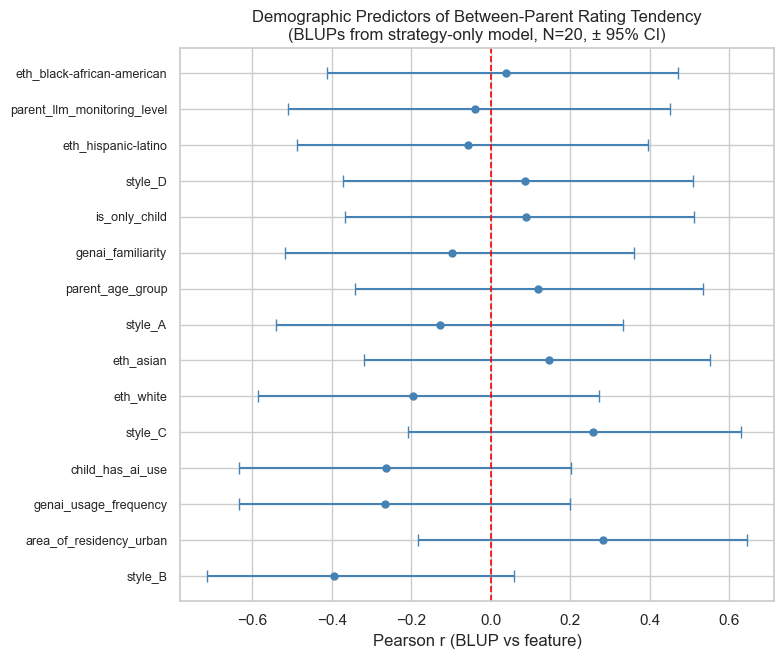

In [5]:
feat_cols = [c for c in df_merged.columns if c not in ['blup', 'blup_se', 'n_highlights']]

rows = []
for col in feat_cols:
    sub = df_merged[['blup', col]].dropna()
    if sub[col].nunique() < 2 or len(sub) < 5:
        continue
    r_p, p_p = pearsonr(sub['blup'], sub[col].astype(float))
    r_s, p_s = spearmanr(sub['blup'], sub[col].astype(float))
    rows.append({
        'feature': col,
        'pearson_r': round(r_p, 3),
        'p_pearson': round(p_p, 4),
        'spearman_r': round(r_s, 3),
        'p_spearman': round(p_s, 4),
        'n': len(sub),
    })

corr_df = pd.DataFrame(rows).sort_values('pearson_r', key=abs, ascending=False)
print('=== Bivariate correlations: feature vs strategy-only BLUP ===')
display(corr_df.reset_index(drop=True))
corr_df.to_csv(OUTPUT_DIR / 'blup_demographics_correlations.csv', index=False)
print('Saved: blup_demographics_correlations.csv')

# Pearson 95% CI via Fisher z transform
def pearson_ci(r, n, alpha=0.05):
    if abs(r) >= 1.0 or n <= 3:
        return r, r
    z = np.arctanh(r)
    se = 1.0 / np.sqrt(n - 3)
    z_crit = norm.ppf(1 - alpha / 2)
    return float(np.tanh(z - z_crit * se)), float(np.tanh(z + z_crit * se))

plot_df = corr_df.head(15).reset_index(drop=True)
cis = [pearson_ci(r, n) for r, n in zip(plot_df['pearson_r'], plot_df['n'])]
lo  = np.array([c[0] for c in cis])
hi  = np.array([c[1] for c in cis])
rs  = plot_df['pearson_r'].values

fig, ax = plt.subplots(figsize=(8, max(5, len(plot_df) * 0.45)))
y = list(range(len(plot_df)))
ax.errorbar(rs, y, xerr=[rs - lo, hi - rs], fmt='o', color='steelblue', capsize=4, markersize=5)
ax.axvline(0, color='red', linestyle='--', lw=1.2)
ax.set_yticks(y)
ax.set_yticklabels(plot_df['feature'], fontsize=9)
ax.set_xlabel('Pearson r (BLUP vs feature)')
ax.set_title(
    'Demographic Predictors of Between-Parent Rating Tendency\n'
    '(BLUPs from strategy-only model, N=20, ± 95% CI)'
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'blup_demographics_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

## R² summary: how much between-parent variance do demographics recover?

Top predictors selected (|r| >= 0.20): ['style_B', 'area_of_residency_urban', 'genai_usage_frequency']
Ridge R² (in-sample):  0.210
Bootstrap R² median:   0.238  95% CI [0.041, 0.547]

Demographics explain 21.0% of between-parent BLUP variance
Equivalent to 10.6% of total sentiment variance

Interpretation: Weak/uncertain demographic signal (CI straddles 0.10).
  Cannot rule out modest utility; recommend collecting calibration ratings.


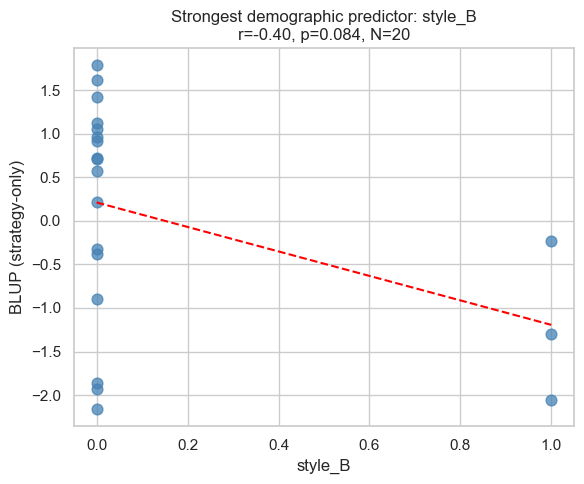

In [6]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

# Select top non-redundant predictors by |pearson_r| >= 0.20
top_feats = corr_df[corr_df['pearson_r'].abs() >= 0.20]['feature'].head(3).tolist()

if not top_feats:
    print('No demographic predictor exceeds |r|=0.20.')
    print('Conclusion: demographics do not explain between-parent BLUP variance.')
    print('Personalization requires calibration ratings — advance profiling is insufficient.')
else:
    sub = df_merged[['blup'] + top_feats].dropna()
    X = sub[top_feats].values.astype(float)
    y = sub['blup'].values

    ridge = Ridge(alpha=1.0).fit(X, y)
    r2_in_sample = r2_score(y, ridge.predict(X))

    # Bootstrap CI (resample parents)
    rng = np.random.default_rng(42)
    boot_r2 = []
    for _ in range(2000):
        idx = rng.integers(0, len(y), len(y))
        Xb, yb = X[idx], y[idx]
        if np.unique(yb).size < 2:
            continue
        boot_r2.append(r2_score(yb, Ridge(alpha=1.0).fit(Xb, yb).predict(Xb)))
    ci_lo, ci_med, ci_hi = np.percentile(boot_r2, [2.5, 50, 97.5])

    # Express as share of total variance (denominator = var_total_strat)
    demo_share_of_between  = r2_in_sample
    demo_share_of_total    = r2_in_sample * var_random_strat / var_total_strat

    print(f'Top predictors selected (|r| >= 0.20): {top_feats}')
    print(f'Ridge R² (in-sample):  {r2_in_sample:.3f}')
    print(f'Bootstrap R² median:   {ci_med:.3f}  95% CI [{ci_lo:.3f}, {ci_hi:.3f}]')
    print()
    print(f'Demographics explain {demo_share_of_between*100:.1f}% of between-parent BLUP variance')
    print(f'Equivalent to {demo_share_of_total*100:.1f}% of total sentiment variance')
    print()

    if ci_lo > 0.10:
        print('Interpretation: Demographics recover meaningful between-parent variance.')
        print(f'  Cold-start estimate from demographics adds ~{demo_share_of_total*100:.0f}pp of recoverable a priori signal.')
    elif ci_hi < 0.10:
        print('Interpretation: Demographics explain negligible between-parent variance.')
        print('  Personalization requires calibration ratings — demographics alone insufficient.')
    else:
        print('Interpretation: Weak/uncertain demographic signal (CI straddles 0.10).')
        print('  Cannot rule out modest utility; recommend collecting calibration ratings.')

    # Scatter for strongest predictor
    best = top_feats[0]
    sub2 = df_merged[['blup', best]].dropna()
    r_best, p_best = pearsonr(sub2['blup'], sub2[best].astype(float))

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(sub2[best].astype(float), sub2['blup'], color='steelblue', alpha=0.75, s=60)
    m, b = np.polyfit(sub2[best].astype(float), sub2['blup'], 1)
    xr = np.linspace(sub2[best].astype(float).min(), sub2[best].astype(float).max(), 100)
    ax.plot(xr, m * xr + b, color='red', lw=1.5, linestyle='--')
    ax.set_xlabel(best)
    ax.set_ylabel('BLUP (strategy-only)')
    ax.set_title(f'Strongest demographic predictor: {best}\nr={r_best:.2f}, p={p_best:.3f}, N={len(sub2)}')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'blup_demographics_best_predictor.png', dpi=150, bbox_inches='tight')
    plt.show()

## Deep-dive: significant demographic variables

N=20 — every panel shows all individual parent points.

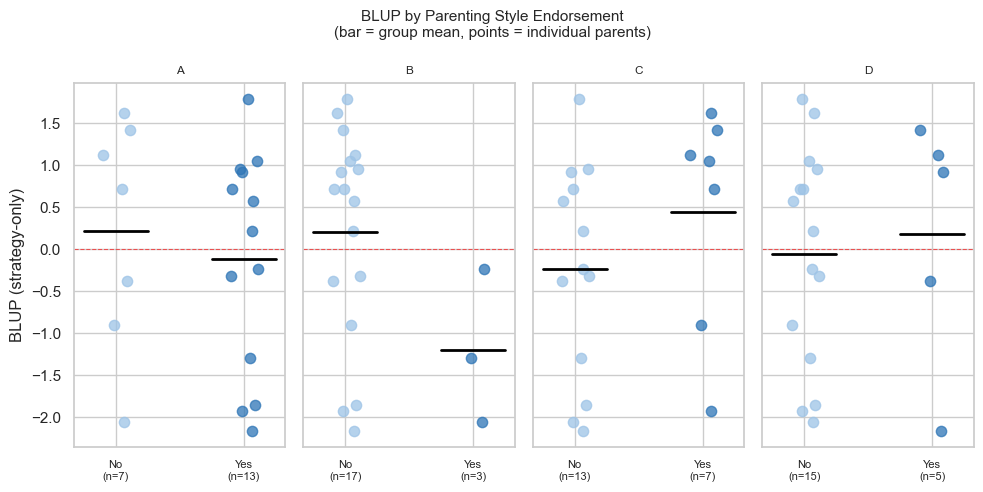

In [7]:
# ── Parenting style: endorser vs non-endorser strip plots ─────────────────────
style_cols = sorted([c for c in df_merged.columns if c.startswith('style_')])

if not style_cols:
    print('No parenting_style columns found in df_merged.')
else:
    n_styles = len(style_cols)
    fig, axes = plt.subplots(1, n_styles, figsize=(max(10, n_styles * 2.2), 5), sharey=True)
    if n_styles == 1:
        axes = [axes]

    for ax, col in zip(axes, style_cols):
        label = col.replace('style_', '')
        sub = df_merged[['blup', col]].dropna()
        groups = sub.groupby(col)['blup']

        for val, color, xpos in [(0, '#9DC3E6', 0), (1, '#2E75B6', 1)]:
            pts = sub.loc[sub[col] == val, 'blup']
            if len(pts) == 0:
                continue
            jitter = np.random.default_rng(42).uniform(-0.12, 0.12, len(pts))
            ax.scatter(xpos + jitter, pts, color=color, alpha=0.75, s=55, zorder=3)
            ax.plot([xpos - 0.25, xpos + 0.25], [pts.mean(), pts.mean()],
                    color='black', lw=2, zorder=4)

        ax.set_xticks([0, 1])
        ax.set_xticklabels([f'No\n(n={int((sub[col]==0).sum())})',
                             f'Yes\n(n={int((sub[col]==1).sum())})'], fontsize=8)
        ax.set_title(label, fontsize=8.5, wrap=True)
        ax.axhline(0, color='red', linestyle='--', lw=0.8, alpha=0.6)

    axes[0].set_ylabel('BLUP (strategy-only)')
    fig.suptitle('BLUP by Parenting Style Endorsement\n(bar = group mean, points = individual parents)', fontsize=11)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'blup_by_parenting_style.png', dpi=150, bbox_inches='tight')
    plt.show()

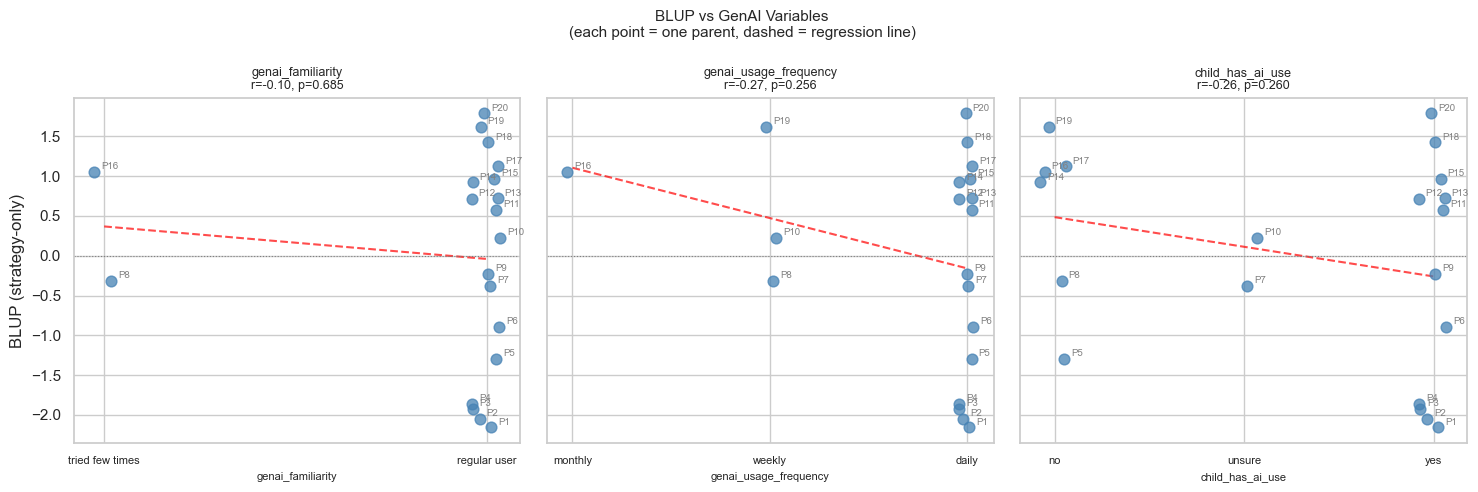

In [8]:
# ── GenAI variables: scatter with labeled points ──────────────────────────────
genai_vars = {
    'genai_familiarity':     {0: 'tried few times', 1: 'regular user'},
    'genai_usage_frequency': {1: 'monthly', 2: 'weekly', 3: 'daily'},
    'child_has_ai_use':      {0: 'no', 0.5: 'unsure', 1: 'yes'},
}
genai_vars = {k: v for k, v in genai_vars.items() if k in df_merged.columns}

if not genai_vars:
    print('No GenAI columns found in df_merged.')
else:
    fig, axes = plt.subplots(1, len(genai_vars),
                             figsize=(5 * len(genai_vars), 5), sharey=True)
    if len(genai_vars) == 1:
        axes = [axes]

    # Short parent labels for annotation
    pid_labels = {pid: f'P{i+1}' for i, pid in enumerate(df_merged.index)}

    for ax, (col, tick_labels) in zip(axes, genai_vars.items()):
        sub = df_merged[['blup', col]].dropna()
        xs = sub[col].astype(float)
        ys = sub['blup']

        jitter = np.random.default_rng(0).uniform(-0.04, 0.04, len(sub))
        ax.scatter(xs + jitter, ys, color='steelblue', alpha=0.75, s=60, zorder=3)

        # Label each point with short parent ID
        for pid, x, y in zip(sub.index, xs, ys):
            ax.annotate(pid_labels[pid], (x + jitter[list(sub.index).index(pid)], y),
                        textcoords='offset points', xytext=(5, 2), fontsize=7, color='gray')

        # Regression line
        if len(sub) > 2 and xs.nunique() > 1:
            m, b = np.polyfit(xs, ys, 1)
            xr = np.linspace(xs.min(), xs.max(), 100)
            ax.plot(xr, m * xr + b, color='red', lw=1.5, linestyle='--', alpha=0.7)
            r_val, p_val = pearsonr(xs, ys)
            ax.set_title(f'{col}\nr={r_val:.2f}, p={p_val:.3f}', fontsize=9)
        else:
            ax.set_title(col, fontsize=9)

        ax.axhline(0, color='gray', linestyle=':', lw=0.8)
        tick_vals = sorted(tick_labels.keys())
        ax.set_xticks(tick_vals)
        ax.set_xticklabels([tick_labels[v] for v in tick_vals], fontsize=8)
        ax.set_xlabel(col, fontsize=8)

    axes[0].set_ylabel('BLUP (strategy-only)')
    fig.suptitle('BLUP vs GenAI Variables\n(each point = one parent, dashed = regression line)', fontsize=11)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'blup_by_genai.png', dpi=150, bbox_inches='tight')
    plt.show()

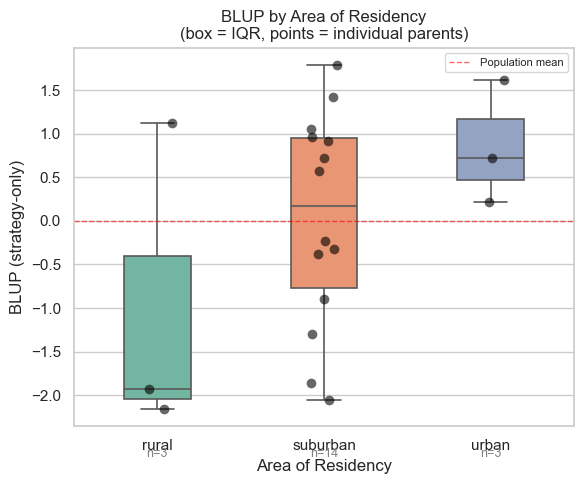

Group means:


,mean,std,count
area_of_residency,,,
rural,-0.987,1.830,3
suburban,0.029,1.221,14
urban,0.851,0.707,3


In [9]:
# ── Area of residency: strip + box with all points labeled ────────────────────
# Reconstruct original categorical from df_sel (was dummified in df_enc)
area_raw = (
    df_sel[['parent_id', 'area_of_residency']]
    .drop_duplicates(subset='parent_id')
    .set_index('parent_id')['area_of_residency']
)
df_area = blup_df[['blup']].join(area_raw).dropna()

if df_area.empty or df_area['area_of_residency'].nunique() < 2:
    print('area_of_residency not available or only one level.')
else:
    area_order = (
        df_area.groupby('area_of_residency')['blup']
        .median()
        .sort_values()
        .index.tolist()
    )
    area_counts = df_area['area_of_residency'].value_counts()

    fig, ax = plt.subplots(figsize=(max(5, len(area_order) * 2), 5))
    palette = sns.color_palette('Set2', len(area_order))

    sns.boxplot(data=df_area, x='area_of_residency', y='blup',
                order=area_order, palette=palette, width=0.4,
                fliersize=0, linewidth=1.2, ax=ax)
    sns.stripplot(data=df_area, x='area_of_residency', y='blup',
                  order=area_order, color='black', alpha=0.6,
                  size=7, jitter=True, ax=ax)

    # Annotate n per group
    for i, cat in enumerate(area_order):
        n = area_counts.get(cat, 0)
        ax.text(i, ax.get_ylim()[0] - 0.08 * (ax.get_ylim()[1] - ax.get_ylim()[0]),
                f'n={n}', ha='center', fontsize=9, color='gray')

    ax.axhline(0, color='red', linestyle='--', lw=1.0, alpha=0.6, label='Population mean')
    ax.set_xlabel('Area of Residency')
    ax.set_ylabel('BLUP (strategy-only)')
    ax.set_title('BLUP by Area of Residency\n(box = IQR, points = individual parents)')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'blup_by_area_of_residency.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('Group means:')
    display(df_area.groupby('area_of_residency')['blup'].agg(['mean', 'std', 'count']).round(3))